In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

# sim_name = f"SunMod_1k"
sim_name = f"SunMod_2k"
# sim_name = f"SunMod_5k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)


#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]


# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

### Precomputations

- Earth velocities from SunEarthGC_frame_coords_local(2024)
- 

### Step-by-step flowchart to arrive at modulations

1. Load neutrino velocity vectors, i.e. output from 1-year simulations.
2. Load Earth velocities.
3. Transform sim velocities into Earth frame
   (issue about boosting to be studied)
4. From here usual process: conversion to momentum, Liouville, integrate.


## Plotting annual modulations

(densities computed in separate .py script)

SunLock_grav_PSD_Earth_frame_wrtCNB_int_pixels
days_dens shape: (31, 1, 5)


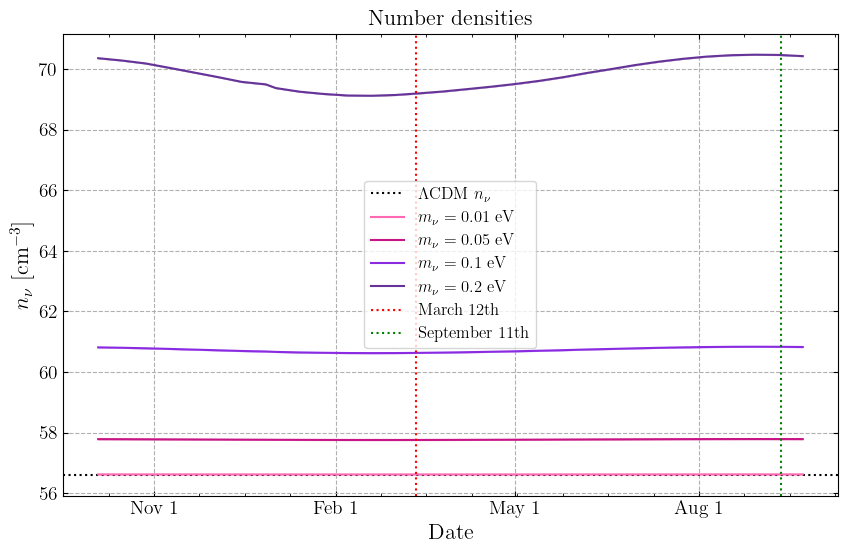

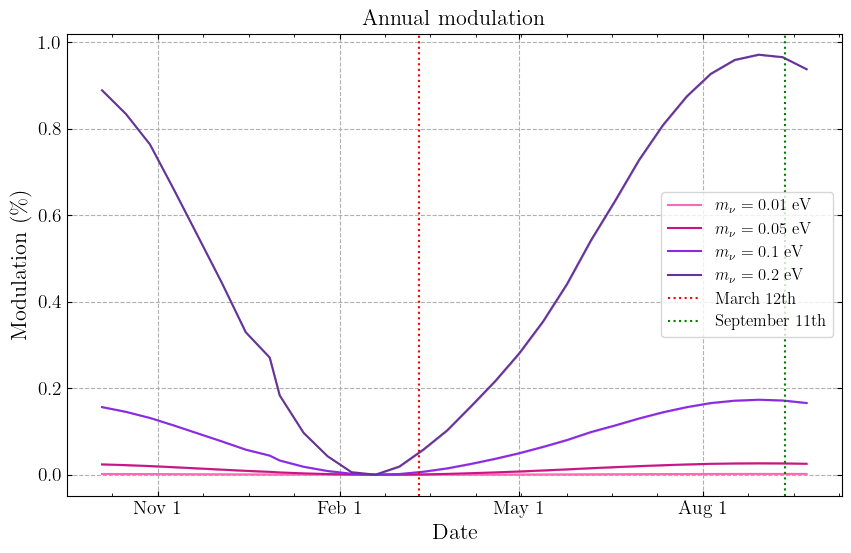

In [ ]:
### ======= ###
### Version ###
### ======= ###

# sim_name = f"SunNoG"
# sim_name = f"SunMod_1k"
sim_name = f"SunMod_2k"
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
# prefix = "NoSun"
# prefix = "SunNoDM"
# prefix = "SunOnly_Dopri5"
# prefix = "SunOnly_Dopri8"
# prefix = "Sun+DM"

# Sun only
prefix = "SunLock"

# Sun + DM halo gravity vector
# prefix = "SunLockDM"
#/including DM gravity in daily sims doesn't induce significant changes
#? but does using PSD from core sim, instead of FD, induce changes?

# versions that are ready are marked with #/

# Sun only (in "SunLock" frame, not Earth's), FD as boundary condition
# suffix = "_FD_PSD_int_pixels"  #/

# Earth's frame: Sun effect, FD as boundary condition
# suffix = "_FD_PSD_Earth_frame_wrtMW_int_pixels"  #/
# suffix = "_FD_PSD_Earth_frame_wrtCNB_int_pixels"  #/ wrong rel. vel.?

# Earth's frame: Sun effect, PSD from DM sim as boundary condition
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"  #/ 10 halos, most correct?

# (using CNB as rel. vel seems not right, as it would not correspond to the
# frame which the DM simulations, and the resulting PSD, are in...)
# suffix = "_grav_PSD_Earth_frame_wrtCNB_int_pixels"  #/ wrong rel. vel.?

# Earth's frame: Bound vs. unbound populations, using PSD from DM sim
# suffix = "_grav_PSD_Earth_frame_wrtMW_bound_int_pixels"  #/
# suffix = "_grav_PSD_Earth_frame_wrtMW_unbound_int_pixels"  #/

# TODO: add log scale option for number density plots, i.e. 1+clus.fac. n/n_0 style as in paper

### =========== ###
### Load & Plot ###
### =========== ###

print(f"{prefix}{suffix}")
days_nums = jnp.load(f"{sim_folder}/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(f"{sim_folder}/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")
# (days, halos, masses)

if suffix == "_FD_PSD_int_pixels":
    print(f"\nSun clustering factors:")
    print(jnp.mean(days_dens[:,0,:], axis=0)/Params.N0_cm3-1)

SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    pdf_path=f"{fig_folder}/densities_{prefix}{suffix}",
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    pdf_path=f"{fig_folder}/modulation_{prefix}{suffix}",
)

## Deflection angles

Day 1
Median deflection angle: 0.46°
1-sigma range: 0.00° - 77.82°
Minimum deflection angle: 0.00°
Maximum deflection angle: 180.00°
Number of non-zero angles: 6143524
Number of zero angles excluded: 476


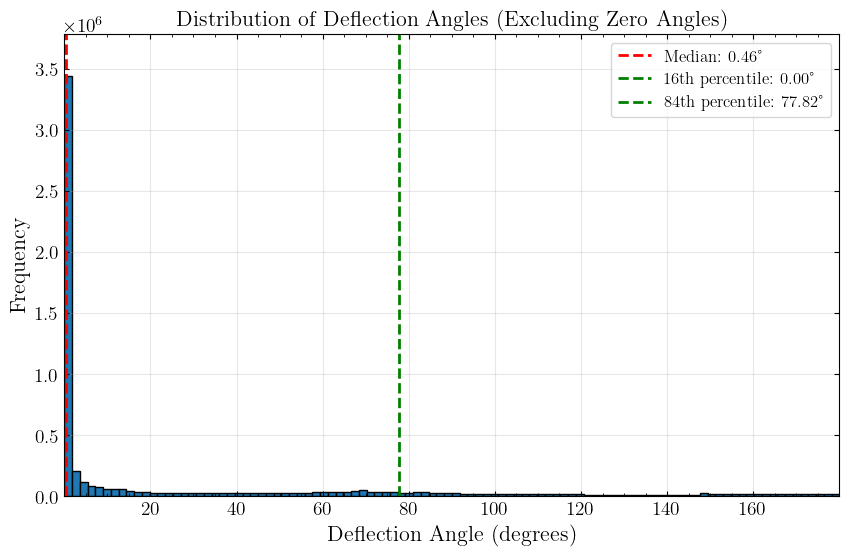

Day 241
Median deflection angle: 0.45°
1-sigma range: 0.00° - 78.16°
Minimum deflection angle: 0.00°
Maximum deflection angle: 180.00°
Number of non-zero angles: 6143517
Number of zero angles excluded: 483


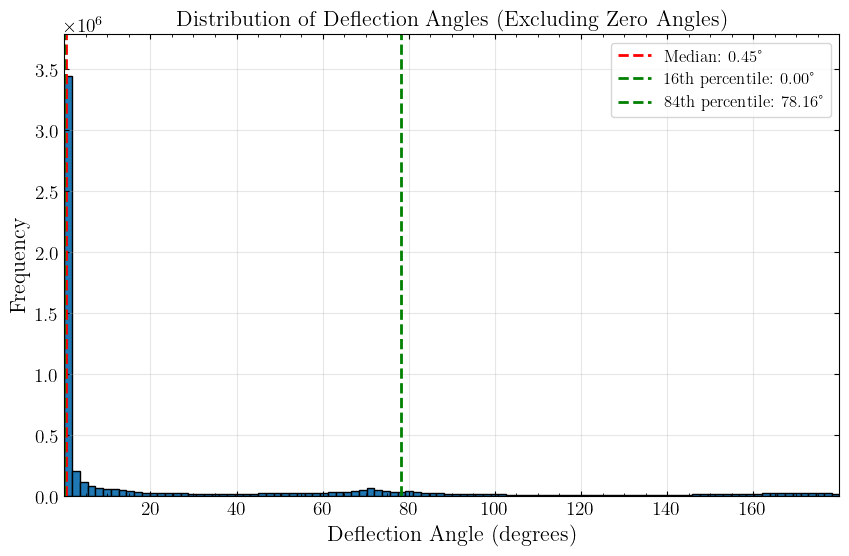

'\n# For Dopri5_1k folder and DM halo files\nfor halo_i in range(3):\n\n    print(f"Halo {halo_i+1}")\n    # Load velocities for current day\n    # Insert dimension at beginning to account for multiple halos later\n    sim_folder_local = f"sim_output/Dopri5_1k"\n    day_vels = jnp.load(\n        f"{sim_folder_local}/vectors_halo{halo_i+1}.npy")[..., 3:].reshape(-1, 2, 3)\n\n    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)\n'

In [9]:
def calculate_deflection_angle(velocity_vectors):
    """
    Calculate the deflection angle between initial and final velocity vectors.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :return: numpy array of deflection angles in degrees
    """
    z0_vels = velocity_vectors[:, 0, :]
    z4_vels = velocity_vectors[:, -1, :]
    
    # Normalize the vectors
    z0_vels_norm = z0_vels / np.linalg.norm(z0_vels, axis=-1)[:, None]
    z4_vels_norm = z4_vels / np.linalg.norm(z4_vels, axis=-1)[:, None]
    
    # Calculate the dot product
    dot_product = np.sum(z0_vels_norm * z4_vels_norm, axis=-1)
    
    # Clip the dot product to [-1, 1] to avoid numerical errors
    dot_product_clipped = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle in radians and convert to degrees
    angles = np.arccos(dot_product_clipped) * 180 / np.pi
    
    return angles


def analyze_and_plot_deflections(velocity_vectors, bins, exclude_zero):
    """
    Analyze deflection angles and create a plot with median and 1-sigma percentiles.
    The plot range is limited to the min and max found values.
    
    :param velocity_vectors: numpy array of shape (N, 2, 3)
    :param exclude_zero: boolean, if True, exclude zero angles from analysis
    """
    deflection_angles = calculate_deflection_angle(velocity_vectors)
    
    if exclude_zero:
        deflection_angles = deflection_angles[deflection_angles > 0]
        if len(deflection_angles) == 0:
            print("No non-zero deflection angles found. Cannot perform analysis.")
            return

    median = np.median(deflection_angles)
    percentile_16 = np.percentile(deflection_angles, 16)
    percentile_84 = np.percentile(deflection_angles, 84)
    
    min_angle = np.min(deflection_angles)
    max_angle = np.max(deflection_angles)
    
    plt.figure(figsize=(10, 6))
    n, bins, patches = plt.hist(deflection_angles, bins=bins, edgecolor='black')
    plt.axvline(
        median, color='r', linestyle='dashed', linewidth=2, 
        label=f'Median: {median:.2f}°')
    plt.axvline(
        percentile_16, color='g', linestyle='dashed', linewidth=2, 
        label=f'16th percentile: {percentile_16:.2f}°')
    plt.axvline(
        percentile_84, color='g', linestyle='dashed', linewidth=2, 
        label=f'84th percentile: {percentile_84:.2f}°')
    
    plt.xlabel('Deflection Angle (degrees)')
    plt.ylabel('Frequency')
    title = 'Distribution of Deflection Angles'
    if exclude_zero:
        title += ' (Excluding Zero Angles)'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Set x-axis limits to min and max found values
    plt.xlim(min_angle, max_angle)
    
    # Adjust y-axis to show full height of the tallest bar
    plt.ylim(0, max(n) * 1.1)
    
    
    print(f"Median deflection angle: {median:.2f}°")
    print(f"1-sigma range: {percentile_16:.2f}° - {percentile_84:.2f}°")
    print(f"Minimum deflection angle: {min_angle:.2f}°")
    print(f"Maximum deflection angle: {max_angle:.2f}°")
    if exclude_zero:
        print(f"Number of non-zero angles: {len(deflection_angles)}")
        print(f"Number of zero angles excluded: {len(velocity_vectors) - len(deflection_angles)}")
    
    plt.show()
    

# """
for day in range(0, 365, 24)[::10]:

    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    print(f"Day {day+1}")
    # sim_folder_local = f"sim_output/SunNoG"
    # sim_folder_local = f"sim_output/SunMod_1k"
    sim_folder_local = f"sim_output/SunMod_2k"
    # days_vecs_dir = f"{sim_folder}/EarthSun_frame_Dopri8"
    # days_vecs_dir = f"{sim_folder_local}/NoSun_vectors"
    days_vecs_dir = f"{sim_folder_local}/SunLock_frame"
    day_vels = jnp.load(
        f"{days_vecs_dir}/vectors_day{day+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
# """


"""
# For Dopri5_1k folder and DM halo files
for halo_i in range(3):

    print(f"Halo {halo_i+1}")
    # Load velocities for current day
    # Insert dimension at beginning to account for multiple halos later
    sim_folder_local = f"sim_output/Dopri5_1k"
    day_vels = jnp.load(
        f"{sim_folder_local}/vectors_halo{halo_i+1}.npy")[..., 3:].reshape(-1, 2, 3)

    analyze_and_plot_deflections(day_vels, bins=100, exclude_zero=True)
"""

In [ ]:
# Directions?:
# - show that modulation curve peak is determined by relative velocity
# - virialisation/isotropy of bound CNB not good assumption?
#   and if all then for small percentage of [0.006, 0.7, 3.9, 12.4, 17.7]
#                                       for [0.01, 0.05, 0.1, 0.2,  0.3] eV

In [ ]:
def Fermi_Dirac_boosted(p_vec, v_boost, args):

    c_unit = args.c#/(args.km/args.s)  # c in our velocity units

    # Get direction of momentum (unit vector)
    p_direction = p_vec / jnp.linalg.norm(p_vec, axis=-1, keepdims=True)

    # Compute Doppler factor
    gamma = 1/jnp.sqrt(1 - jnp.sum(v_boost**2)/c_unit**2)
    doppler_val = gamma * (1 - jnp.sum(v_boost*p_direction, axis=-1)/c_unit)

    # Apply Doppler factor to temperature
    T_effective = args.T_CNB / doppler_val

    p_mag = jnp.linalg.norm(p_vec, axis=-1)

    return 1/(jnp.exp(p_mag/T_effective) + 1)

In [ ]:
def p_orig_from_p_prime(p_prime_vec, v_boost, mass=0):
    
    # Compute gamma factor
    beta_squared = jnp.sum(v_boost**2)#/c**2, but c=1 in our Params units
    gamma = 1/jnp.sqrt(1 - beta_squared)
    
    # Compute energy in boosted frame
    p_prime_mag = jnp.linalg.norm(p_prime_vec, axis=-1)
    E_prime = jnp.sqrt(p_prime_mag**2 + mass**2)
    
    # Get beta hat (unit vector in boost direction)
    beta_hat = v_boost/jnp.linalg.norm(v_boost)
    
    # Compute dot product of beta_hat and p_prime
    beta_dot_p = jnp.sum(beta_hat * p_prime_vec, axis=-1, keepdims=True)
    
    # Compute p in original frame
    p_orig = (p_prime_vec + 
              beta_hat * (gamma-1) * beta_dot_p - 
              gamma * v_boost * E_prime[..., None])
    
    return p_orig

In [ ]:
def transform_CNB_to_Earth_frame(
        p_CNB_vec, v_boost, phase_space_vals):
    """
    Transform phase-space distribution from CNB to Earth frame using general Lorentz transformation.
    """
    # Compute gamma factor
    beta_squared = jnp.sum(v_boost**2)  # assuming natural units, c=1
    gamma = 1/jnp.sqrt(1 - beta_squared)
    
    # Energy in CNB frame (massive particles)
    p_mag_CNB = jnp.linalg.norm(p_CNB_vec, axis=-1, keepdims=True)
    E_CNB = jnp.sqrt(p_mag_CNB**2 + mass**2)
    
    # Compute β·p
    beta_dot_p = jnp.sum(v_boost * p_CNB_vec, axis=-1, keepdims=True)
    
    # Transform to Earth frame using general Lorentz transformation
    p_Earth = (p_CNB_vec + 
               (gamma-1) * beta_dot_p * v_boost/beta_squared - 
               gamma * v_boost * E_CNB)
    
    # Phase space measure transforms with factor 1/(γ(1 - β·p̂))
    p_direction = p_CNB_vec / p_mag_CNB
    doppler_val = gamma * (1 - jnp.sum(v_boost*p_direction, axis=-1))
    measure_factor = 1/doppler_val
    
    # Phase space density is Lorentz invariant
    f_Earth = phase_space_vals
    
    return p_Earth, f_Earth, measure_factor


def number_density_Earth_frame(
        p_CNB_vec, phase_space_vals, v_boost, pix_sr, args):
    """
    Compute number density in Earth frame.
    
    Args:
        p_CNB_vec: Momentum vectors in CNB frame
        phase_space_vals: Values of f(p) in CNB frame
        v_boost: Earth's velocity relative to CNB
        pix_sr: Pixel solid angle
        args: Parameters object
    """
    # Transform to Earth frame
    p_Earth, f_Earth, measure_factor = transform_CNB_to_Earth_frame(
        p_CNB_vec, v_boost, phase_space_vals)
    
    # Compute magnitude of transformed momenta
    p_Earth_mag = jnp.linalg.norm(p_Earth, axis=-1)
    
    # Calculate number density with correct measure
    # p^3 dp dΩ → p^3 dp dΩ / γ(1 - β·p̂)
    y = p_Earth_mag**3 * f_Earth * measure_factor
    x = p_Earth_mag
    n_raw = trap(y, jnp.log(x), axis=-1)
    
    # Multiply by constants and convert units
    n_cm3 = pix_sr * args.g_nu/((2*args.Pi)**3) * n_raw / (1/args.cm**3)
    
    return n_cm3


# For each day:
n_density_Earth = number_density_Earth_frame(
    p_CNB_vec=p_vec_z0_sort,  # your initial momenta
    phase_space_vals=your_f_of_p_values,  # your phase space values
    v_boost=earth_vels[day],
    pix_sr=4*Params.Pi/simdata.Npix,
    args=Params()
)